In [100]:
import numpy as np
import qiskit 
from qiskit.circuit import QuantumRegister, QuantumCircuit, Parameter
from qiskit.quantum_info import Pauli, SparsePauliOp
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
import random

import matplotlib.pyplot as plt

import pandas as pd

import scipy.optimize as opt

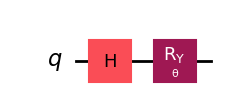

In [101]:
def A_gates(l):
    A = QuantumCircuit(1)

    match(l):
        case 0:
            pass # identity 
        case 1: 
            A.x(0)
        case 2: 
            A.z(0)
    return A

coeffs = [1, 0.5, 0.5]

def ansatz():
    V = QuantumCircuit(1)

    param = Parameter('θ')

    V.h(0)
    V.ry(param, 0)

    return V, param

ansatz()[0].draw('mpl')


In [102]:
A = np.array([
    [1.5, 0.5],
    [0.5, -0.5]
])
b = np.array([[1/np.sqrt(2)], [1/np.sqrt(2)]])
np.linalg.inv(A) @ b, 1/np.sqrt(2), np.linalg.det(A)

(array([[ 0.70710678],
        [-0.70710678]]),
 np.float64(0.7071067811865475),
 np.float64(-1.0))

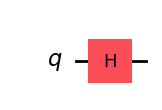

In [103]:
def U():
    u = QuantumCircuit(1)
    u.h(0)
    return u

U().draw('mpl')

In [104]:
V, θ = ansatz()

def get_expvals(θ, l=None, lp=None, j=1):
    # extract expectation values from the circuit
    
    # first lets build the circuit

    vqls = QuantumCircuit(1)

    # variational form
    vqls.compose(V, inplace=True)
    vqls.barrier()

    # A_l
    vqls.compose(A_gates(l), inplace=True)
    vqls.barrier()

    # Ub
    vqls.compose(U(), inplace=True)
    vqls.barrier()

    if j==1:
        vqls.z(0)
        vqls.barrier()

    vqls.compose(U(), inplace=True)
    vqls.barrier()

    vqls.compose(A_gates(lp), inplace=True)
    vqls.barrier()

    vqls.compose(V, inplace=True)

    # display(vqls.draw('mpl'))

    observables = [[SparsePauliOp(["Z"])]]
    estimator = StatevectorEstimator()

    pub = (vqls, observables, [θ])
    job = estimator.run([pub])

    evs = job.result()[0].data.evs
    mu = evs[0][0]

    return mu
    
def norm(θ):
    norm = 0.0

    for l in range(0, len(coeffs)):
        for lp in range(0, len(coeffs)):
            norm += coeffs[l] * np.conj(coeffs[lp]) * get_expvals(θ, l, lp, j=-1)

    return abs(norm)

norm(9)

np.float64(0.9999999999999993)

In [105]:

def cost_function(θ):

    mu_sum = 0.0

    for l in range(0, len(coeffs)):
            for lp in range(0, len(coeffs)):
                mu_sum += coeffs[l] * np.conj(coeffs[lp]) * get_expvals(θ, l, lp)

    mu_sum = abs(mu_sum)

    # compute cost func
    return 0.5 - 0.5 * mu_sum / (norm(θ))
    

cost_function(2)


np.float64(0.17317818956819397)

array(3.88578059e-16)

 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 3.885780586188048e-16
       x: [ 1.840e-08]
     nit: 26
   maxcv: 0.0
    nfev: 15

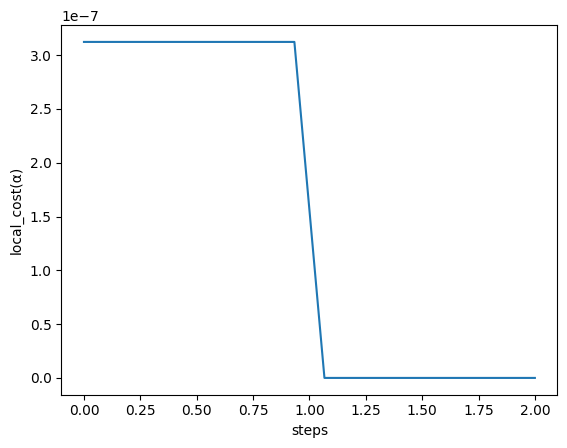

In [106]:
α = [0.001 * random.random()]

history = []
def log_step(xk):
    cost = cost_function(xk)
    history.append(np.copy(cost))

# history.append(np.copy())
log_step(α)

res = opt.minimize(cost_function, α, method="COBYQA", callback=log_step)

xs = np.linspace(0, 2, len(history))

plt.plot(xs, [h for h in history])
plt.xlabel("steps")
plt.ylabel("local_cost(α)")
display(history[-1])
res


In [ ]:
opt = res.x
opt

variational_form = QuantumCircuit(1)
variational_form.compose(V, inplace=True)

bound = variational_form.assign_parameters(opt)
variational_form.draw('mpl')

bound.measure_all()

n_shots = 1000000

sampler = StatevectorSampler()
job = sampler.run([bound], shots=n_shots)
result = job.result()[0]

counts = result.data.meas.get_counts()
probs = {k: v / n_shots for k, v in counts.items()}

statevector = np.zeros(2)
for bitstr, p in probs.items():
    idx = int(bitstr, 2)
    statevector[idx] = p #np.sqrt(p)  # use the probabilites

# statevector /= np.linalg.norm(statevector)
display(probs)
display(statevector)

{'0': 0.4959, '1': 0.5041}

array([0.4959, 0.5041])